# Introduction

This notebook explores Formula 1 race data with the goal of uncovering trends and insights through data exploration, statistical analysis, and programmatic tooling. Using data sourced from the OpenF1 API, this project examines driver performance, lap consistency, positional changes, and racing dynamics throughout the 2024 Formula 1 season.

The analysis leverages modular design and object-oriented programming (OOP) principles to ensure reusable and scalable workflows. By cleaning, transforming, and visualizing the data, the project aims to identify patterns that could inform future forecasting or predictive modeling efforts in motorsport analytics.


## Scope

- The dataset is filtered to include only the most recently completed F1 season (2024).
- Only full races are analyzed; sprint races are excluded from this study.
- Except where noted (e.g., qualifying comparisons), analysis is focused exclusively on main event race sessions.
- All data is retrieved dynamically from the [OpenF1 API](https://openf1.org/), using custom-built API queries and transformation functions.



In [2]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Part One: Getting the Data


The first step in any exploratory data analysis is acquiring the data. For this project, I used the OpenF1 API, which provides a variety of useful endpoints related to Formula 1 telemetry, session data, drivers, and more.

Initially, I attempted to build a single class to encapsulate all endpoint queries through reusable helper functions. However, as the project evolved, I opted for a more modular approach—calling and processing only the endpoints I needed, when I needed them. This allowed for faster iteration and flexibility as the analysis progressed.


In [4]:
meetings_data = requests.get(f'https://api.openf1.org/v1/meetings?year=2024').json()
meetings_df = pd.DataFrame(meetings_data)
#Clearing out columns I don't need
meetings_df_clean = meetings_df[['meeting_key', 'circuit_short_name', 'meeting_name', 'location', 'country_name']]
display(meetings_df_clean)

,meeting_key,circuit_short_name,meeting_name,location,country_name
0,1228,Sakhir,Pre-Season Testing,Sakhir,Bahrain
1,1229,Sakhir,Bahrain Grand Prix,Sakhir,Bahrain
2,1230,Jeddah,Saudi Arabian Grand Prix,Jeddah,Saudi Arabia
3,1231,Melbourne,Australian Grand Prix,Melbourne,Australia
4,1232,Suzuka,Japanese Grand Prix,Suzuka,Japan
5,1233,Shanghai,Chinese Grand Prix,Shanghai,China
6,1234,Miami,Miami Grand Prix,Miami,United States
7,1235,Imola,Emilia Romagna Grand Prix,Imola,Italy
8,1236,Monte Carlo,Monaco Grand Prix,Monaco,Monaco
9,1237,Montreal,Canadian Grand Prix,Montréal,Canada


In [5]:
#We are only going to focus on actual races, not sprints or practice events
#using Qualifiers and Race data to compare performances
sessions_data = requests.get(f'https://api.openf1.org/v1/sessions?year=2024').json()
sessions_df = pd.DataFrame(sessions_data)
sessions_df = sessions_df[sessions_df['session_type'] != 'Practice']
sessions_df = sessions_df[sessions_df['session_name'].isin(['Qualifying', 'Race'])]
sessions_df_clean = sessions_df[['meeting_key', 'session_key', 'session_type', 'session_name']]

display(sessions_df_clean)

,meeting_key,session_key,session_type,session_name
6,1229,9468,Qualifying,Qualifying
7,1229,9472,Race,Race
11,1230,9476,Qualifying,Qualifying
12,1230,9480,Race,Race
16,1231,9484,Qualifying,Qualifying
17,1231,9488,Race,Race
21,1232,9492,Qualifying,Qualifying
22,1232,9496,Race,Race
26,1233,9664,Qualifying,Qualifying
27,1233,9673,Race,Race


In [6]:
###
# Create our first draft at a merged dataset
###

race_master = meetings_df_clean.merge(sessions_df_clean[['session_key', 'meeting_key', 'session_type']], on=['meeting_key'], how='left')
#race_master['session_key'].astype('str')
#Let's update this so it's only focused on the main events.
race_master = race_master[race_master['session_type'] != 'Qualifying']
race_master = race_master.dropna(subset='session_key')
display(race_master)

,meeting_key,circuit_short_name,meeting_name,location,country_name,session_key,session_type
2,1229,Sakhir,Bahrain Grand Prix,Sakhir,Bahrain,9472.0,Race
4,1230,Jeddah,Saudi Arabian Grand Prix,Jeddah,Saudi Arabia,9480.0,Race
6,1231,Melbourne,Australian Grand Prix,Melbourne,Australia,9488.0,Race
8,1232,Suzuka,Japanese Grand Prix,Suzuka,Japan,9496.0,Race
10,1233,Shanghai,Chinese Grand Prix,Shanghai,China,9673.0,Race
12,1234,Miami,Miami Grand Prix,Miami,United States,9507.0,Race
14,1235,Imola,Emilia Romagna Grand Prix,Imola,Italy,9515.0,Race
16,1236,Monte Carlo,Monaco Grand Prix,Monaco,Monaco,9523.0,Race
18,1237,Montreal,Canadian Grand Prix,Montréal,Canada,9531.0,Race
20,1238,Catalunya,Spanish Grand Prix,Barcelona,Spain,9539.0,Race


In [7]:
###
# Generate a list of session ID's
###

sessions_ids = race_master['session_key'].unique().astype('int').astype('str')
#sessions_ids = race_master['session_key'].astype('str')
display(sessions_ids)

array(['9472', '9480', '9488', '9496', '9673', '9507', '9515', '9523',
       '9531', '9539', '9550', '9558', '9566', '9574', '9582', '9590',
       '9598', '9606', '9617', '9625', '9636', '9644', '9655', '9662'],
      dtype='<U11')

In [8]:
###
# Getting crafty with a for loop to iteratively make calls based on the sessions
###


drivers = []

for sessionkey in sessions_ids:
    url = f'https://api.openf1.org/v1/drivers?session_key={sessionkey}'
    driver_data = requests.get(url).json()

    drivers.extend(driver_data)

drivers_df = pd.DataFrame(drivers)
drivers_df_clean = drivers_df.drop_duplicates()
display(drivers_df_clean)



,meeting_key,session_key,driver_number,broadcast_name,full_name,name_acronym,team_name,team_colour,first_name,last_name,headshot_url,country_code
0,1229,9472,1,M VERSTAPPEN,Max VERSTAPPEN,VER,Red Bull Racing,3671c6,Max,Verstappen,https://media.formula1.com/d_driver_fallback_i...,NED
1,1229,9472,2,L SARGEANT,Logan SARGEANT,SAR,Williams,64c4ff,Logan,Sargeant,https://media.formula1.com/d_driver_fallback_i...,USA
2,1229,9472,3,D RICCIARDO,Daniel RICCIARDO,RIC,RB,6692ff,Daniel,Ricciardo,https://media.formula1.com/d_driver_fallback_i...,AUS
3,1229,9472,4,L NORRIS,Lando NORRIS,NOR,McLaren,ff8000,Lando,Norris,https://media.formula1.com/d_driver_fallback_i...,GBR
4,1229,9472,10,P GASLY,Pierre GASLY,GAS,Alpine,ff87bc,Pierre,Gasly,https://media.formula1.com/d_driver_fallback_i...,FRA
...,...,...,...,...,...,...,...,...,...,...,...,...
474,1252,9662,55,C SAINZ,Carlos SAINZ,SAI,Ferrari,E80020,Carlos,Sainz,https://media.formula1.com/d_driver_fallback_i...,ESP
475,1252,9662,61,J DOOHAN,Jack DOOHAN,DOO,Alpine,0093cc,Jack,Doohan,None,AUS
476,1252,9662,63,G RUSSELL,George RUSSELL,RUS,Mercedes,27F4D2,George,Russell,https://media.formula1.com/d_driver_fallback_i...,GBR
477,1252,9662,77,V BOTTAS,Valtteri BOTTAS,BOT,Kick Sauber,52e252,Valtteri,Bottas,https://media.formula1.com/d_driver_fallback_i...,FIN


In [9]:
all_laps = []

for sessionkey in sessions_ids:
    url = f'https://api.openf1.org/v1/laps?session_key={sessionkey}'
    lap_data = requests.get(url).json()

    all_laps.extend(lap_data)

laps_df = pd.DataFrame(all_laps)
display(laps_df)

,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed
0,1229,9472,1,2,2024-03-02T15:05:20.099000+00:00,30.916,41.661,23.719,232.0,248.0,False,96.296,"[2049, 2049, 2049, 2049, 2048, 2051, 2049, 204...","[2048, 2048, 2048, 2048, 2048, 2048, 2048, 204...","[2048, 2048, 2048, 2049, 2048, 2048, 2049]",287.0
1,1229,9472,16,2,2024-03-02T15:05:21.019000+00:00,31.166,41.864,23.832,NaN,240.0,False,96.862,"[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2048, 2048, 2048, 2048, 2048, 204...","[2048, 2048, 2048, 2049, 2049, 2048, 2048]",293.0
2,1229,9472,63,2,2024-03-02T15:05:22.022000+00:00,30.829,42.038,23.768,230.0,253.0,False,96.635,"[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2048, 2048, 2049, 2048, 2049, 204...","[2048, 2048, 2049, 2051, 2048, 2048, 2049]",298.0
3,1229,9472,11,2,2024-03-02T15:05:22.877000+00:00,30.678,41.867,23.996,234.0,257.0,False,96.541,"[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2048, 2049, 2049, 2049, 204...","[2048, 2048, 2049, 2049, 2048, 2049, 2049]",302.0
4,1229,9472,55,2,2024-03-02T15:05:23.374000+00:00,30.974,42.366,23.896,235.0,244.0,False,97.236,"[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2048, 2049, 2048, 2049, 2048, 2049, 204...","[2049, 2048, 2048, 2048, 2048, 2048, 2048]",297.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26607,1252,9662,55,1,None,NaN,38.437,32.859,285.0,289.0,True,NaN,"[2048, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2051, 204...","[2049, 2049, 2049, 2051, 2051, 2051, 2049, 204...",298.0
26608,1252,9662,61,1,None,NaN,40.549,35.991,285.0,277.0,True,NaN,"[2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...",291.0
26609,1252,9662,63,1,None,NaN,38.837,33.002,285.0,297.0,True,NaN,"[2048, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2051, 205...",312.0
26610,1252,9662,77,1,None,NaN,41.546,35.018,277.0,294.0,True,NaN,"[2048, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...",294.0


In [10]:
results = []

for sessionkey in sessions_ids:
    url = f'https://api.openf1.org/v1/session_result?session_key={sessionkey}'
    result_data = requests.get(url).json()

    results.extend(result_data)

results_df = pd.DataFrame(results)
display(results_df)

,position,driver_number,number_of_laps,points,dnf,dns,dsq,duration,gap_to_leader,meeting_key,session_key
0,1.0,1,57.0,26.0,False,False,False,5504.742,0,1229,9472
1,2.0,11,57.0,18.0,False,False,False,5527.199,22.457,1229,9472
2,3.0,55,57.0,15.0,False,False,False,5529.852,25.11,1229,9472
3,4.0,16,57.0,12.0,False,False,False,5544.411,39.669,1229,9472
4,5.0,63,57.0,10.0,False,False,False,5551.530,46.788,1229,9472
...,...,...,...,...,...,...,...,...,...,...,...
474,16.0,20,57.0,0.0,False,False,False,NaN,+1 LAP,1252,9662
475,17.0,30,55.0,0.0,True,False,False,NaN,None,1252,9662
476,NaN,11,0.0,0.0,True,False,False,NaN,None,1252,9662
477,NaN,43,26.0,0.0,True,False,False,NaN,None,1252,9662


In [16]:
pits = []

for sessionkey in sessions_ids:
    url = f'https://api.openf1.org/v1/pit?session_key={sessionkey}'
    pit_data = requests.get(url).json()

    pits.extend(pit_data)

pit_df = pd.DataFrame(pits)
display(pit_df)

,date,session_key,meeting_key,driver_number,pit_duration,lap_number
0,2024-03-02T15:06:11.115000+00:00,9472,1229,27,36.6,1.0
1,2024-03-02T15:19:05.235000+00:00,9472,1229,24,25.2,9.0
2,2024-03-02T15:19:07.623000+00:00,9472,1229,18,24.4,9.0
3,2024-03-02T15:20:46.058000+00:00,9472,1229,31,24.8,10.0
4,2024-03-02T15:21:55.789000+00:00,9472,1229,2,35.7,10.0
...,...,...,...,...,...,...
822,2024-12-08T13:53:15.464000+00:00,9662,1252,81,32.7,32.0
823,2024-12-08T13:55:40.057000+00:00,9662,1252,44,21.6,34.0
824,2024-12-08T14:00:33.594000+00:00,9662,1252,14,22.4,37.0
825,2024-12-08T14:03:51.327000+00:00,9662,1252,24,28.7,39.0


In [18]:
###
# Final version of my merged dataset for analysis
###


f1_master = race_master.merge(laps_df[['meeting_key', 'session_key', 'driver_number', 'lap_duration', 'lap_number', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'i1_speed', 'i2_speed', 'is_pit_out_lap','st_speed']], on=['meeting_key', 'session_key'], how='left' )
f1_master = f1_master.merge(drivers_df_clean[['driver_number', 'session_key', 'full_name', 'team_name', 'team_colour']], on=['driver_number','session_key'], how='left')
f1_master = f1_master.merge(pit_df[['meeting_key', 'session_key', 'lap_number', 'pit_duration']], on=['session_key', 'meeting_key', 'lap_number'], how='left')
f1_master['team_colour'] = '#' + f1_master['team_colour'].astype(str)

driver_palette = dict(zip( f1_master['driver_number'], f1_master['team_colour'])) #Creating a palette for graphs based on team colors

f1_master = f1_master.merge(results_df[['meeting_key', 'session_key', 'driver_number', 'dnf', 'dns', 'dsq', 'position']], on=['meeting_key', 'session_key', 'driver_number'], how='left')
f1_master['session_key'] = f1_master['session_key'].astype('int')
display(f1_master)

,meeting_key,circuit_short_name,meeting_name,location,country_name,session_key,session_type,driver_number,lap_duration,lap_number,...,is_pit_out_lap,st_speed,full_name,team_name,team_colour,pit_duration,dnf,dns,dsq,position
0,1229,Sakhir,Bahrain Grand Prix,Sakhir,Bahrain,9472,Race,1,96.296,2,...,False,287.0,Max VERSTAPPEN,Red Bull Racing,#3671c6,NaN,False,False,False,1.0
1,1229,Sakhir,Bahrain Grand Prix,Sakhir,Bahrain,9472,Race,16,96.862,2,...,False,293.0,Charles LECLERC,Ferrari,#e8002d,NaN,False,False,False,4.0
2,1229,Sakhir,Bahrain Grand Prix,Sakhir,Bahrain,9472,Race,63,96.635,2,...,False,298.0,George RUSSELL,Mercedes,#27f4d2,NaN,False,False,False,5.0
3,1229,Sakhir,Bahrain Grand Prix,Sakhir,Bahrain,9472,Race,11,96.541,2,...,False,302.0,Sergio PEREZ,Red Bull Racing,#3671c6,NaN,False,False,False,2.0
4,1229,Sakhir,Bahrain Grand Prix,Sakhir,Bahrain,9472,Race,55,97.236,2,...,False,297.0,Carlos SAINZ,Ferrari,#e8002d,NaN,False,False,False,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33942,1252,Yas Marina Circuit,Abu Dhabi Grand Prix,Yas Island,United Arab Emirates,9662,Race,55,NaN,1,...,True,298.0,Carlos SAINZ,Ferrari,#E80020,NaN,False,False,False,2.0
33943,1252,Yas Marina Circuit,Abu Dhabi Grand Prix,Yas Island,United Arab Emirates,9662,Race,61,NaN,1,...,True,291.0,Jack DOOHAN,Alpine,#0093cc,NaN,False,False,False,15.0
33944,1252,Yas Marina Circuit,Abu Dhabi Grand Prix,Yas Island,United Arab Emirates,9662,Race,63,NaN,1,...,True,312.0,George RUSSELL,Mercedes,#27F4D2,NaN,False,False,False,5.0
33945,1252,Yas Marina Circuit,Abu Dhabi Grand Prix,Yas Island,United Arab Emirates,9662,Race,77,NaN,1,...,True,294.0,Valtteri BOTTAS,Kick Sauber,#52e252,NaN,True,False,False,NaN


# Initial Look

## Overview

This section provides an initial overview of the 2024 Formula 1 season, displaying race-by-race results and driver performances for all completed sessions. 

The purpose of this exploration is to:

- Familiarize ourselves with the structure and completeness of the dataset
- Identify trends or anomalies across different races
- Guide the selection of metrics worth investigating more deeply
- Determine potential predictors of performance or race outcomes

This baseline will help inform the data cleaning, feature engineering, and modeling strategies used in later stages of the analysis.


In [20]:
#The widgets came in very handy getting the most out of the data formatting and testing cases.

meeting_dropdown = widgets.Dropdown(
    options=f1_master['meeting_name'].unique(),
    description='2024 Race:',
)

def update_plot1(meeting_key):
    '''
    Used to push the values of the dropdown through to the visuals
    '''
    selected_meeting = meeting_key 
    print(f"Selected Meeting: {selected_meeting}")
    
    update_df = f1_master[f1_master['meeting_name'] == selected_meeting]

    # Remove outliers (IQR filter)
    Q1 = update_df['lap_duration'].quantile(0.25)
    Q3 = update_df['lap_duration'].quantile(0.75)
    IQR = Q3 - Q1
    filtered_df = update_df[(update_df['lap_duration'] >= Q1 - 1.5 * IQR) &
                            (update_df['lap_duration'] <= Q3 + 1.5 * IQR)]

    avg_laptime = filtered_df['lap_duration'].mean()

    final_laps = (
    update_df.sort_values('lap_number')
    .groupby('driver_number')
    .tail(1)
    )
    
    # Convert 'position' to numeric — non-numeric values become NaN
    final_laps['position'] = pd.to_numeric(final_laps['position'], errors='coerce')
    
    # Drop drivers with naN
    final_laps = final_laps.dropna(subset=['position'])
    final_laps['position'] = final_laps['position'].astype(int)
    
    # Create final_positions Series
    final_positions = final_laps.set_index('driver_number')['position'].sort_values()
    sorted_drivers = final_positions.index.tolist()


    filtered_df = filtered_df[filtered_df['driver_number'].isin(sorted_drivers)]
    filtered_df['driver_number'] = pd.Categorical(filtered_df['driver_number'], categories=sorted_drivers, ordered=True)

    summary_stats = (
    filtered_df.groupby('driver_number', observed=False)['lap_duration']
    .agg(avg_lap_time='mean', std_lap_time='std', num_laps='count')
    .round(3)
    )
    
    summary_stats['final_position'] = final_positions
    
    name_map = update_df[['driver_number', 'full_name']].drop_duplicates().set_index('driver_number')['full_name']
    summary_stats['full_name'] = summary_stats.index.map(name_map)

    summary_stats = summary_stats[['full_name', 'avg_lap_time', 'std_lap_time', 'num_laps', 'final_position']]
    
    # Reorder by final position
    summary_stats = summary_stats.loc[sorted_drivers]
    display(summary_stats.style.background_gradient(subset=["avg_lap_time", "std_lap_time","num_laps", "final_position"], cmap='viridis'))
        
    #Establish my figure for plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 2]})

    # --- Boxplot ---
    sns.boxplot(
        x='driver_number',
        y='lap_duration',
        data=update_df,
        showfliers=False,
        hue='driver_number',
        order=sorted_drivers,
        palette=driver_palette,
        ax=ax1,
        legend=False
    )
    ax1.axhline(y=avg_laptime, color='red', linestyle='--', linewidth=1.5, label='Avg Lap Time')
    ax1.set_title(f'Lap Time Distribution — Meeting: {meeting_key}')
    ax1.set_ylabel('Lap Time (s)')

    # --- Heatmap ---
    pivot = filtered_df.pivot_table(index='driver_number', columns='lap_number', values='lap_duration', observed=False)
    sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': 'Lap Time (s)'}, ax=ax2)
    ax2.set_title('Race Pace Progression')
    ax2.set_xlabel('Lap Number')
    ax2.set_ylabel('Driver Number')

    plt.tight_layout()
    plt.show()

widgets.interactive(update_plot1, meeting_key=meeting_dropdown)

interactive(children=(Dropdown(description='2024 Race:', options=('Bahrain Grand Prix', 'Saudi Arabian Grand P…

# Analysis 1:
## RacePace Consistency
### How efficiently are drivers driving during each race?


Based on the Exploratory Data Analysis above, most of the drivers who win major events have the lowest, or one of the lowest, average racepaces throughout the race. 

Do drivers who have a lower racepace consistently outperform those who may have one or two exceptional laps?

Is there a reason why the top performers are consistently having better laps during the second half of the race than those who are underperforming in an event?

In [22]:
driver_dropdown = widgets.Dropdown(
    options=sorted(f1_master['full_name'].dropna().unique()),
    description='Driver:',
)

def plot_driver_rolling_std(driver_name):
    driver_df = f1_master[
        (f1_master['full_name'] == driver_name) &
        (~f1_master['is_pit_out_lap'])
    ].copy()

    if driver_df.empty:
        print(f"No valid lap data for {driver_name}.")
        return

    session_groups = driver_df.groupby('session_key')
    n_sessions = len(session_groups)
    n_cols = 2
    n_rows = (n_sessions + 1) // 2  

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4), sharex=False)
    axes = axes.flatten()

    # Session label mapping
    label_map = driver_df[['session_key', 'meeting_name']].drop_duplicates()
    label_map = label_map.set_index('session_key').apply(
        lambda row: f"{row['meeting_name']}", axis=1
    ).to_dict()

    for ax, (session_key, session_df) in zip(axes, session_groups):
        session_df = session_df.sort_values('lap_number')
        session_df['rolling_std'] = session_df['lap_duration'].rolling(window=5).std()
        label = label_map.get(session_key, f"Session {session_key}")

        # Plot lap time on left axis
        ax.plot(session_df['lap_number'], session_df['lap_duration'], label='Lap Time', color='red', alpha=0.6)
        ax.set_xlabel('Lap')
        ax.set_ylabel('Lap Time (s)', color='black')
        ax.tick_params(axis='y', labelcolor='black')

        # Add right y-axis for rolling std
        ax2 = ax.twinx()
        ax2.plot(session_df['lap_number'], session_df['rolling_std'], label='Rolling STD', color='blue')
        ax2.set_ylabel('Rolling STD', color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

        ax.set_title(label)
        ax.grid(True)

    # Hide any unused axes
    for j in range(len(session_groups), len(axes)):
        fig.delaxes(axes[j])

    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

widgets.interactive(plot_driver_rolling_std, driver_name=driver_dropdown)


interactive(children=(Dropdown(description='Driver:', options=('Alexander ALBON', 'Carlos SAINZ', 'Charles LEC…

# Part 2: Logistic Regression

## P(WIN | Race Characteristics)

We can use the average racepace and the deviation used to calculate consistency to predict who will win a race, and thanks to the imbalance, who is much more likely to lose a race.

because it is utilizing Categorical data, the lack of aggregate data should be easier to predict than the linear regression. 


              precision    recall  f1-score   support

           0       0.95      0.54      0.69       110
           1       0.06      0.50      0.10         6

    accuracy                           0.53       116
   macro avg       0.50      0.52      0.39       116
weighted avg       0.91      0.53      0.66       116

{0: 62, 1: 54}


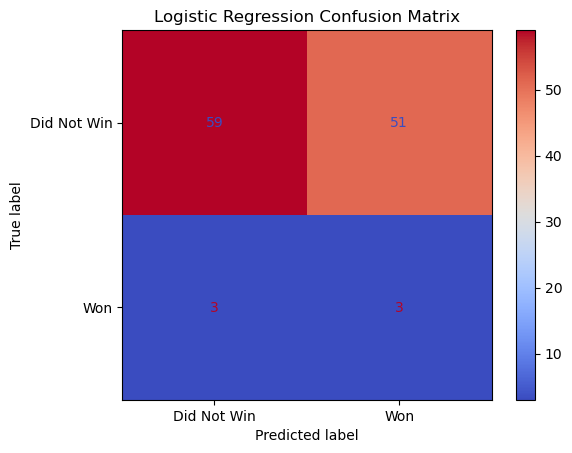

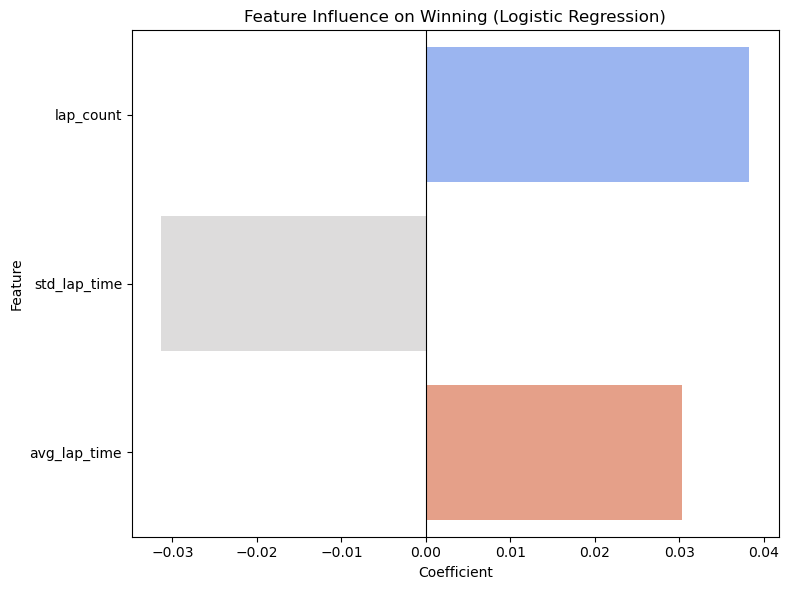

In [23]:
driver_summary = (
    f1_master[~f1_master['is_pit_out_lap']]
    .groupby(['session_key', 'driver_number'])
    .agg(
        avg_lap_time=('lap_duration', 'mean'),
        std_lap_time=('lap_duration', 'std'),
        lap_count=('lap_duration', 'count'),
        final_position=('position', 'last'),
        full_name=('full_name', 'last'),
    )
    .reset_index()
)

driver_summary['win'] = (driver_summary['final_position'] == 1).astype(int)

features = ['avg_lap_time', 'std_lap_time', 'lap_count']
X = driver_summary[features]
X = X.fillna(X.mean())
y = driver_summary['win']


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

model = LogisticRegression(class_weight='balanced') #Added to try and smooth it out a little
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))


pd.Series(model.coef_[0], index=features)

unique, counts = np.unique(y_pred, return_counts=True)
print(dict(zip(unique, counts)))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Win', 'Won'])
disp.plot(cmap='coolwarm')

plt.title('Logistic Regression Confusion Matrix')
plt.show()


coeffs = model.coef_[0]
features = X.columns
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coeffs})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', hue='Feature', palette='coolwarm')
plt.title('Feature Influence on Winning (Logistic Regression)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Part 3: Linear Regression  
## First-Half vs. Second-Half Performances

Does the first half of a race set a driver up for success?  
Is there a general trend where **winning drivers post their best lap times in the second half** of the race?

While logistic regression helped confirm that we can effectively predict which drivers are unlikely to win, it doesn’t help us **analyze or compare driver performance as the race unfolds**.

From our EDA, we noticed that **top-performing drivers consistently deliver some of their best lap times in the second half**. This leads us to a few key questions:

- Is this a trend we can **quantify and test**?
- Can we use second-half improvement as a signal that a driver is likely to **outperform their first-half pace**?
- Does this provide a window into **mid-race positioning and final placement prediction**?

And finally, an important philosophical conundrum:

> _Can I pay my student loans with sports betting money?_  
> Technically, yes. Strategically... maybe let's get the model working first.



R^2 Score: 0.225


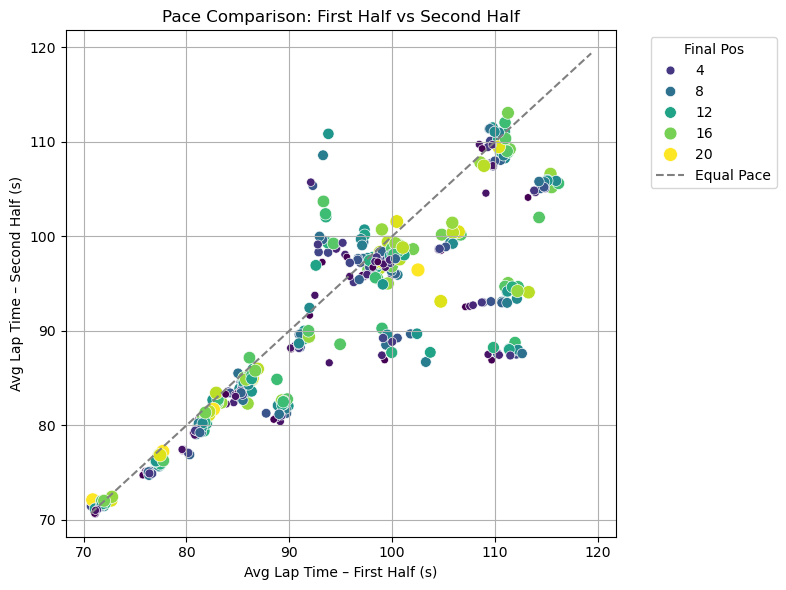

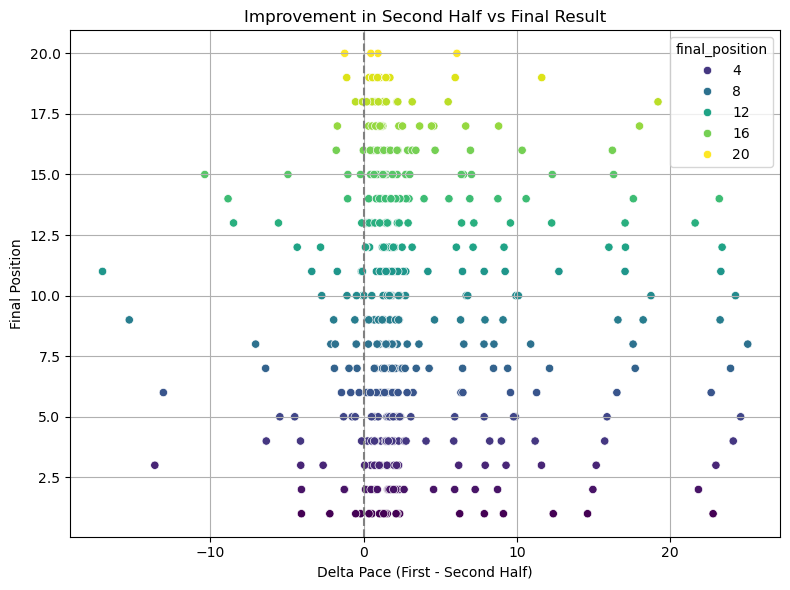

In [26]:
clean_df = f1_master[~f1_master['is_pit_out_lap']].copy()

# Get total laps per session
lap_counts = clean_df.groupby('session_key')['lap_number'].max().reset_index()
lap_counts = lap_counts.rename(columns={'lap_number': 'total_laps'})

# Merge total laps into main DF
clean_df = clean_df.merge(lap_counts, on='session_key')

# Label each lap as 'first_half' or 'second_half'
clean_df['race_half'] = np.where(
    clean_df['lap_number'] <= clean_df['total_laps'] / 2, 'first_half', 'second_half'
)

# Average lap times by half
half_stats = (
    clean_df.groupby(['session_key', 'driver_number', 'race_half'])['lap_duration']
    .mean()
    .unstack()
    .reset_index()
    .rename(columns={'first_half': 'avg_lap_first_half', 'second_half': 'avg_lap_second_half'})
)

# Final position
final_position = (
    f1_master.sort_values('lap_number')
    .groupby(['session_key', 'driver_number'])
    .tail(1)[['session_key', 'driver_number', 'position']]
    .rename(columns={'position': 'final_position'})
)

# Merge all
model_df = half_stats.merge(final_position, on=['session_key', 'driver_number'])
model_df['final_position'] = pd.to_numeric(model_df['final_position'], errors='coerce')

model_df['delta_pace'] = model_df['avg_lap_first_half'] - model_df['avg_lap_second_half']
model_df['improved_pace'] = (model_df['delta_pace'] > 0).astype(int)

X = model_df[['avg_lap_first_half', 'avg_lap_second_half', 'delta_pace']]
y = model_df['improved_pace']

# Drop NaNs
X = X.dropna()
y = y.loc[X.index].dropna()
X = X.loc[y.index]

#Regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print(f"R^2 Score: {r2_score(y_test, y_pred):.3f}")


plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=model_df,
    x='avg_lap_first_half',
    y='avg_lap_second_half',
    hue='final_position',
    palette='viridis',
    size='final_position',
    sizes=(30, 100),
    legend='brief'
)
plt.plot([model_df['avg_lap_first_half'].min(), model_df['avg_lap_first_half'].max()],
         [model_df['avg_lap_first_half'].min(), model_df['avg_lap_first_half'].max()],
         linestyle='--', color='gray', label='Equal Pace')

plt.xlabel("Avg Lap Time – First Half (s)")
plt.ylabel("Avg Lap Time – Second Half (s)")
plt.title("Pace Comparison: First Half vs Second Half")
plt.legend(title='Final Pos', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=model_df, x='delta_pace', y='final_position', hue='final_position', palette='viridis')
plt.axvline(0, linestyle='--', color='gray')
plt.xlabel("Delta Pace (First - Second Half)")
plt.ylabel("Final Position")
plt.title("Improvement in Second Half vs Final Result")
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
model_df['improved'] = (model_df['delta_pace'] > 0).astype(int)

from scipy.stats import ttest_ind

improved = model_df[model_df['improved'] == 1]['final_position'].dropna()
not_improved = model_df[model_df['improved'] == 0]['final_position'].dropna()

t_stat, p_value = ttest_ind(improved, not_improved, equal_var=False)
print(f"T-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")

T-statistic: 1.009, p-value: 0.3157


# Part 4: Class-Based Approach

This section was my first real attempt to bring object-oriented programming (OOP) into the project. I started out with the idea of building a class to handle API calls and structure the data flow more cleanly — but as the project evolved, the class became more of an experiment than a fully developed solution.

That said, there were some fun wins here. I got the class to play nicely with widgets, and it was cool to see how I could pass variable data dynamically to generate visualizations on the fly. While this part isn’t as polished or fully utilized as I originally imagined, it lays some groundwork for building a more organized and reusable toolset in the future.

It’s a bit rough around the edges — but it shows potential, and that’s part of the learning process.



In [32]:
class DriverPerformanceAnalyzer:
    def __init__(self, driver_name, df):
        self.driver_name = driver_name
        self.df = df[df['full_name'] == driver_name].copy()
        self.clean_df = self._clean_laps()
        self.half_avg = None  

    def _clean_laps(self):
        df = self.df[~self.df['is_pit_out_lap']].copy()
        lap_counts = df.groupby('session_key')['lap_number'].max().reset_index()
        lap_counts = lap_counts.rename(columns={'lap_number': 'total_laps'})
        df = df.merge(lap_counts, on='session_key')
        df['race_half'] = np.where(
            df['lap_number'] <= df['total_laps'] / 2,
            'first_half', 'second_half'
        )
        return df

    def get_avg_lap_time_by_half(self):
        half_avg = (
            self.clean_df
            .groupby(['meeting_name', 'race_half'])['lap_duration']
            .mean()
            .unstack(fill_value=np.nan)
            .rename(columns={
                'first_half': 'avg_lap_first_half',
                'second_half': 'avg_lap_second_half'
            })
        )
        self.half_avg = half_avg
        return half_avg

    def get_delta_pace(self):
        if self.half_avg is None:
            self.get_avg_lap_time_by_half()
        delta_df = self.half_avg.copy()
        if 'avg_lap_first_half' not in delta_df.columns or 'avg_lap_second_half' not in delta_df.columns:
            raise ValueError("One of the halves is missing from the data. Cannot compute delta pace.")
        delta_df['delta_pace'] = (
            delta_df['avg_lap_first_half'] - delta_df['avg_lap_second_half']
        )
        return delta_df[['delta_pace']]

    def plot_lap_times(self):

        # Create pivot table without averaging
        pivot_df = (self.clean_df.groupby(['meeting_name', 'lap_number'])['lap_duration'].mean().unstack())

    
        # Plot heatmap
        plt.figure(figsize=(14, max(6, 0.4 * len(pivot_df))))
        sns.heatmap(pivot_df, cmap='viridis', cbar_kws={'label': 'Lap Time (s)'})
        plt.title(f"Lap Times Heatmap for {self.driver_name}")
        plt.xlabel("Lap Number")
        plt.ylabel("Meeting")
        plt.tight_layout()
        plt.show()

    def summary(self):
        delta = self.get_delta_pace()
        print(f"\nDriver: {self.driver_name}")
        display(delta)


In [34]:
def update_driver_analysis(driver_name):
    '''
    Used to update information for the class based analysis below
    '''
    analyzer = DriverPerformanceAnalyzer(driver_name, f1_master)
    analyzer.plot_lap_times()
    analyzer.summary()

driver_dropdown = widgets.Dropdown(
    options=sorted(f1_master['full_name'].dropna().unique()),
    description='Driver:'
)

interactive_widget = widgets.interactive(update_driver_analysis, driver_name=driver_dropdown)
display(interactive_widget)

interactive(children=(Dropdown(description='Driver:', options=('Alexander ALBON', 'Carlos SAINZ', 'Charles LEC…

## Conclusion


While the original objective was to develop a predictive model capable of identifying the eventual race winner using early-race indicators such as Lap 1 position and mid-race pace trends, this proved more difficult than expected. Despite multiple modeling attempts—including logistic and linear regression—none yielded strong predictive power. R² values were consistently low, and statistical tests failed to show significant relationships between early performance and final outcomes.

However, the project achieved several key goals across the data science pipeline:

- **Object-Oriented Programming**: Implemented a class-based structure to encapsulate analysis logic for individual drivers.
- **Data Cleaning and Preparation**: Merged multiple datasets, handled missing values, and engineered relevant features from raw telemetry.
- **Exploratory Data Analysis**: Investigated lap times, pace consistency, and performance trends using both aggregate and session-specific views.
- **Function Abstraction**: Developed reusable functions for key processing and visualization steps, improving modularity and readability.
- **Modular Design**: Created interactive components using widgets for dynamic analysis of sessions and drivers.
- **Visualization**: Produced a variety of plots—boxplots, heatmaps, scatter plots, and rolling statistics—to uncover patterns and support hypothesis testing.

These components collectively form a strong analytical framework that can be extended and refined in future work. Directions for further investigation might include:

- Incorporating more granular telemetry such as tire compounds, pit strategies, or sector times.
- Leveraging advanced modeling approaches, such as ensemble methods or time-series models.
- Expanding the dataset to include multiple seasons for broader generalization and historical pattern recognition.

Although predicting the winner remains elusive, the analytical tools developed here provide a powerful starting point for deeper F1 performance analysis.

*Conclusion edited by ChatGPT for cleanliness*
